In [1]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pyproj import Transformer
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [7]:
df = pd.read_csv("C:/Users/LHansen/OneDrive - Land Information New Zealand/2025/Python/Scripts/Survey_Hire_converted_coordinates.csv")

print(df.head())

   Unnamed: 0             x            y             z        date station  \
0  2025-01-02 -5.086144e+06  474091.0483 -3.806570e+06  2025-01-02    SHAR   
1  2025-01-02 -5.075448e+06  449762.7552 -3.823648e+06  2025-01-02    SHPA   
2  2025-01-02 -5.080592e+06  455839.1905 -3.816163e+06  2025-01-02    SHML   
3  2025-01-02 -5.102936e+06  475377.4854 -3.784051e+06  2025-01-02    SHSA   
4  2025-01-02 -5.089287e+06  480377.6683 -3.801700e+06  2025-01-02    SHMD   

   nztm2000_lon  nztm2000_lat  nzvd2016_elev  
0  5.917390e+06  1.749254e+06        14.8110  
1  5.895579e+06  1.772103e+06        17.0595  
2  5.905075e+06  1.766696e+06        30.0702  
3  5.945495e+06  1.750023e+06        32.1813  
4  5.923616e+06  1.743395e+06        68.0670  


In [8]:
print(df.columns)


Index(['Unnamed: 0', 'x', 'y', 'z', 'date', 'station', 'nztm2000_lon',
       'nztm2000_lat', 'nzvd2016_elev'],
      dtype='object')


In [4]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

In [5]:


# Ensure 'date' is a datetime type
df['date'] = pd.to_datetime(df['date'])

# Set 'date' as the index
df.set_index('date', inplace=True)

# Function to calculate RMS
def calculate_rms(series):
    return np.sqrt(np.mean(series**2))

# Resample data to fortnightly and monthly time series
fortnightly_data = df.groupby(['station', pd.Grouper(freq='2W')])[
    ['nztm2000_lon', 'nztm2000_lat', 'nzvd2016_elev']
].mean().reset_index()

monthly_data = df.groupby(['station', pd.Grouper(freq='ME')])[
    ['nztm2000_lon', 'nztm2000_lat', 'nzvd2016_elev']
].mean().reset_index()

# Calculate RMS for each component of coordinate for each station on a fortnightly time series
fortnightly_rms = fortnightly_data.groupby('station').agg({
    'nztm2000_lon': calculate_rms,
    'nztm2000_lat': calculate_rms,
    'nzvd2016_elev': calculate_rms
}).rename(columns={
    'nztm2000_lon': 'nztm2000_lon_rms',
    'nztm2000_lat': 'nztm2000_lat_rms',
    'nzvd2016_elev': 'nzvd2016_elev_rms'
})

# Calculate RMS for each component of coordinate for each station on a monthly time series
monthly_rms = monthly_data.groupby('station').agg({
    'nztm2000_lon': calculate_rms,
    'nztm2000_lat': calculate_rms,
    'nzvd2016_elev': calculate_rms
}).rename(columns={
    'nztm2000_lon': 'nztm2000_lon_rms',
    'nztm2000_lat': 'nztm2000_lat_rms',
    'nzvd2016_elev': 'nzvd2016_elev_rms'
})

# Print the results
print("Fortnightly RMS values:")
print(fortnightly_rms)
print("\nMonthly RMS values:")
print(monthly_rms)


Fortnightly RMS values:
         nztm2000_lon_rms  nztm2000_lat_rms  nzvd2016_elev_rms
station                                                       
SHAR         5.917390e+06      1.749254e+06          14.810413
SHMD         5.923616e+06      1.743395e+06          68.068996
SHML         5.905075e+06      1.766696e+06          30.079513
SHPA         5.895579e+06      1.772103e+06          17.061691
SHSA         5.945495e+06      1.750023e+06          32.180600

Monthly RMS values:
         nztm2000_lon_rms  nztm2000_lat_rms  nzvd2016_elev_rms
station                                                       
SHAR         5.917390e+06      1.749254e+06          14.810413
SHMD         5.923616e+06      1.743395e+06          68.068996
SHML         5.905075e+06      1.766696e+06          30.079513
SHPA         5.895579e+06      1.772103e+06          17.061691
SHSA         5.945495e+06      1.750023e+06          32.180600


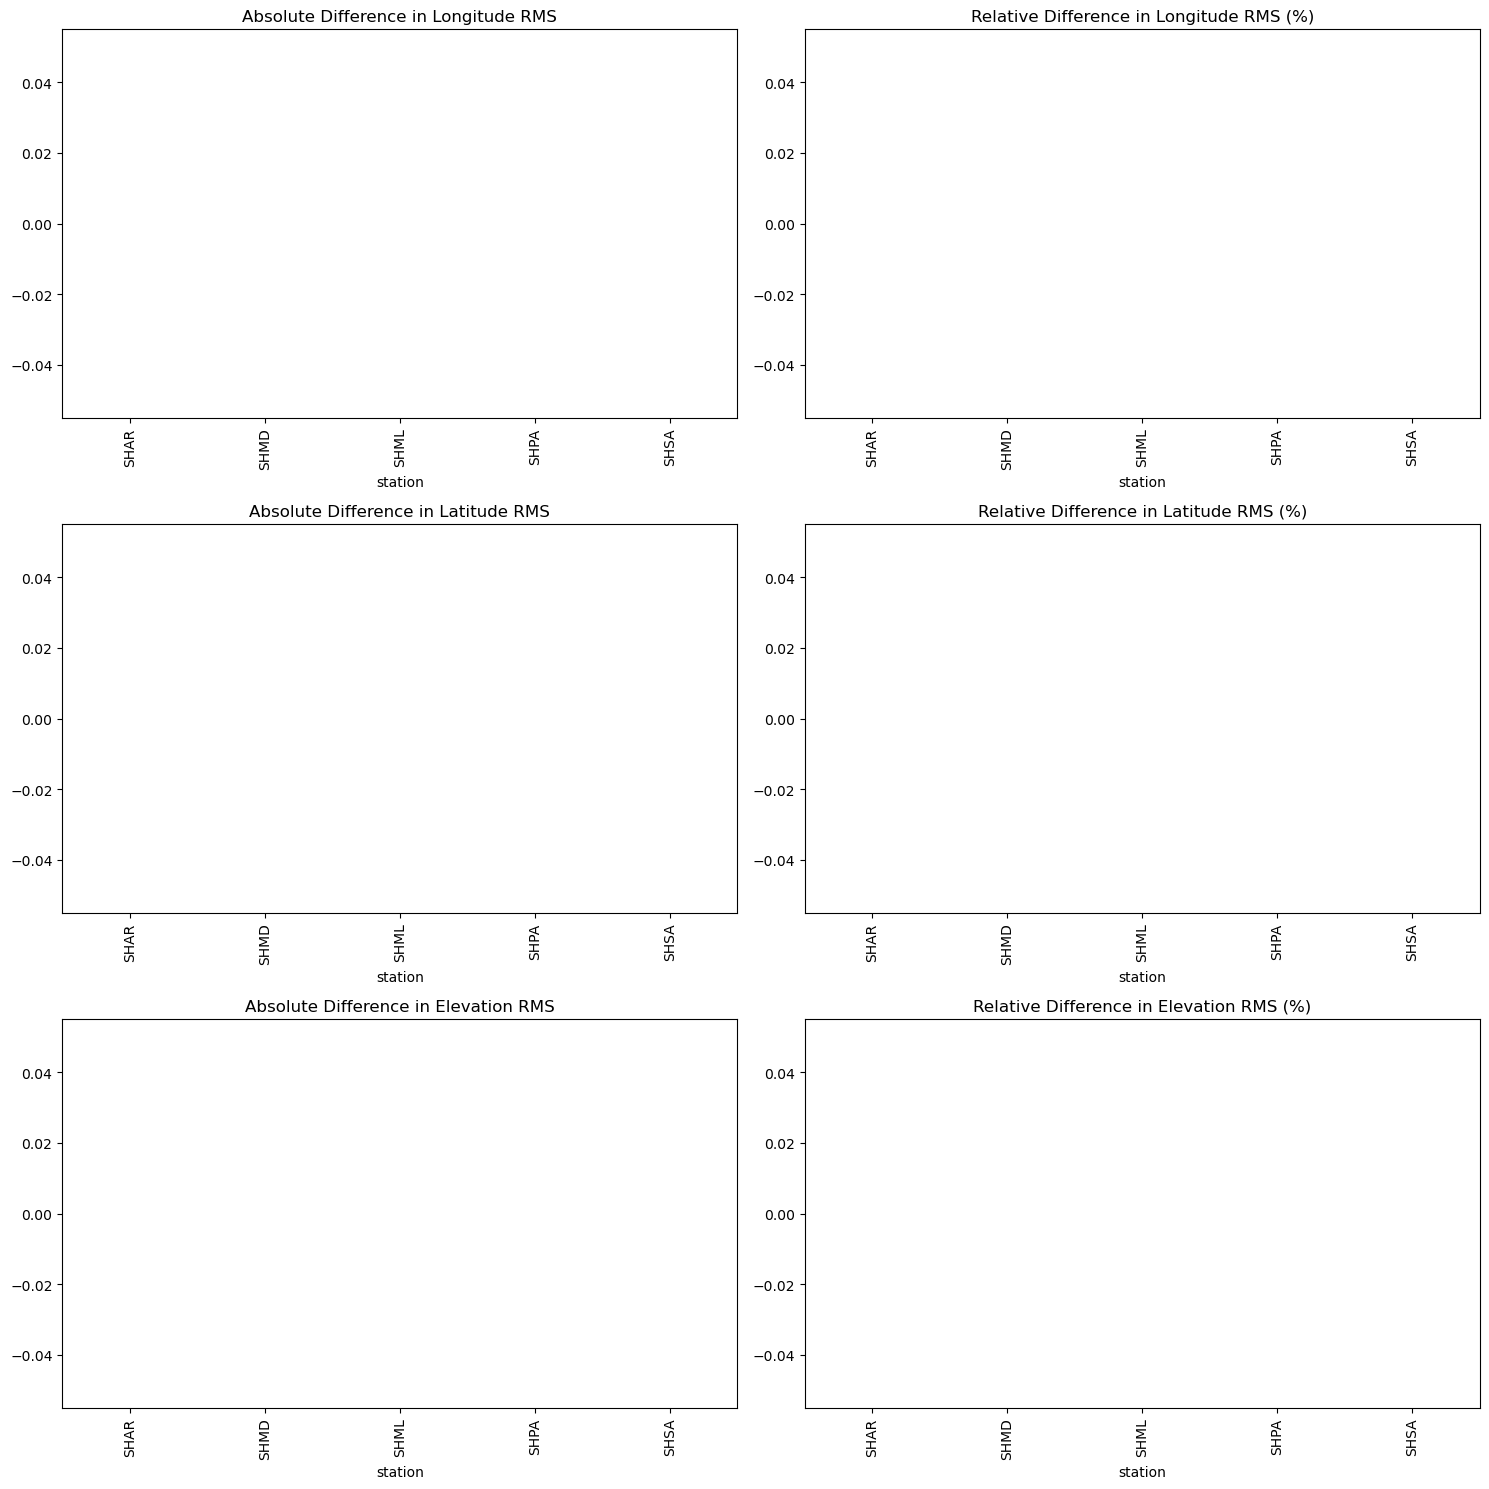

In [6]:
# Assuming you already have these from your earlier code
# fortnightly_rms and monthly_rms are DataFrames with station as index

# Calculate absolute and relative differences
absolute_diff = fortnightly_rms - monthly_rms
relative_diff = (absolute_diff / monthly_rms) * 100

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Absolute differences
absolute_diff['nztm2000_lon_rms'].plot(kind='bar', ax=axes[0, 0], title='Absolute Difference in Longitude RMS')
absolute_diff['nztm2000_lat_rms'].plot(kind='bar', ax=axes[1, 0], title='Absolute Difference in Latitude RMS')
absolute_diff['nzvd2016_elev_rms'].plot(kind='bar', ax=axes[2, 0], title='Absolute Difference in Elevation RMS')

# Relative differences
relative_diff['nztm2000_lon_rms'].plot(kind='bar', ax=axes[0, 1], title='Relative Difference in Longitude RMS (%)')
relative_diff['nztm2000_lat_rms'].plot(kind='bar', ax=axes[1, 1], title='Relative Difference in Latitude RMS (%)')
relative_diff['nzvd2016_elev_rms'].plot(kind='bar', ax=axes[2, 1], title='Relative Difference in Elevation RMS (%)')



# Layout adjustments
plt.tight_layout()
fig.savefig("PositioNZ_rms_comparison.jpg", dpi=300, bbox_inches='tight')
plt.show()



In [9]:
print(df['date'].isnull().sum())


0


In [10]:
print(df['date'].dtype)


object


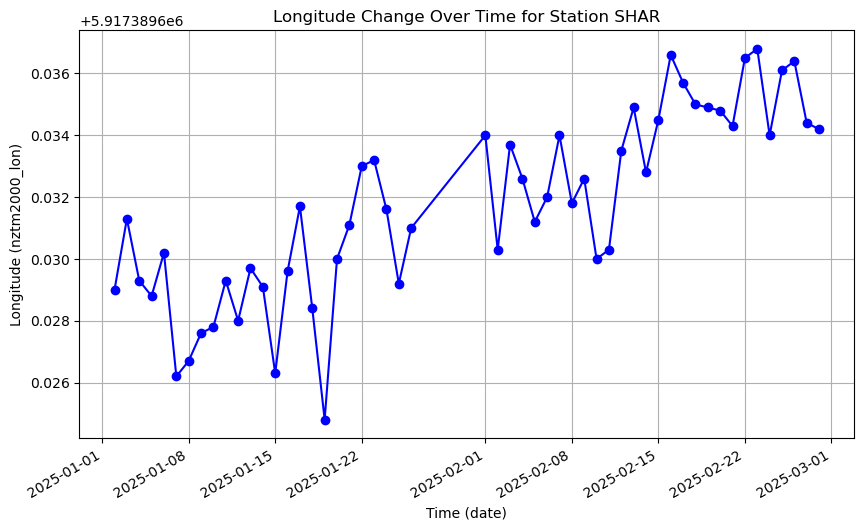

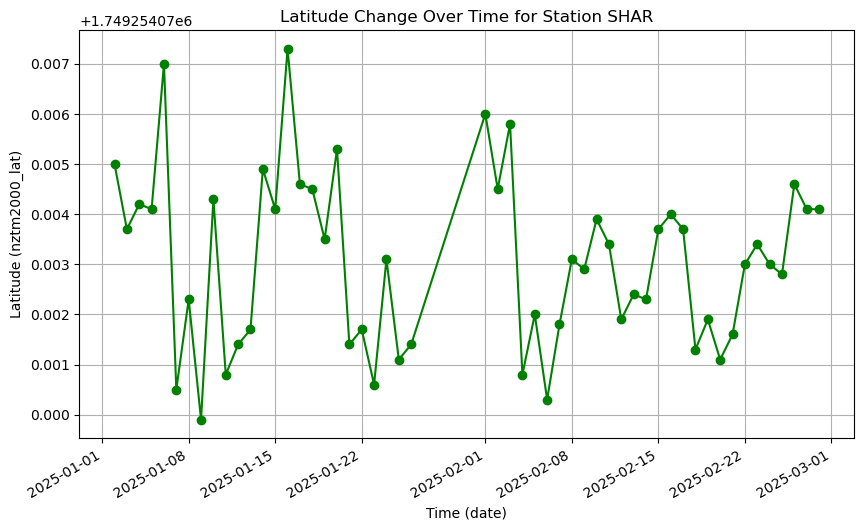

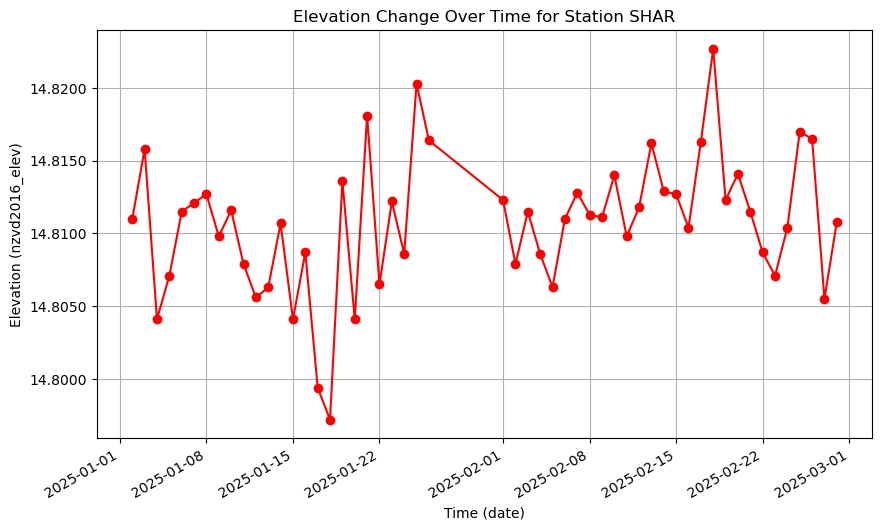

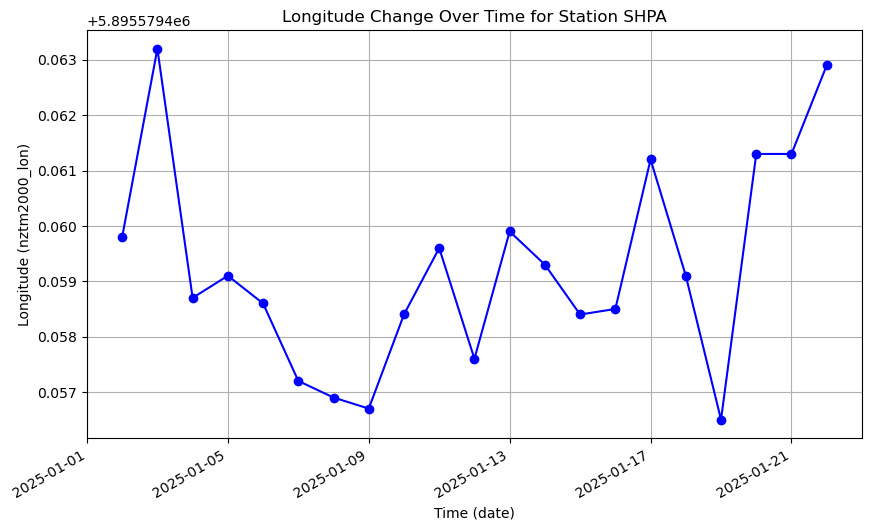

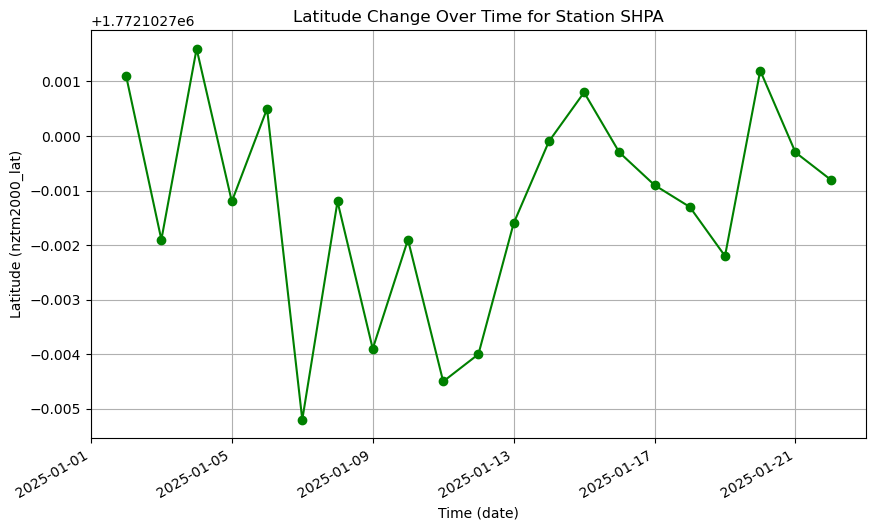

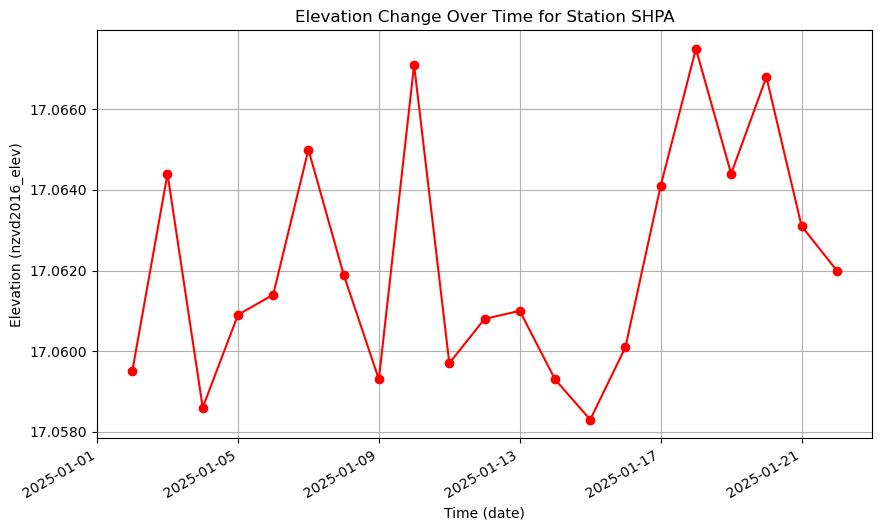

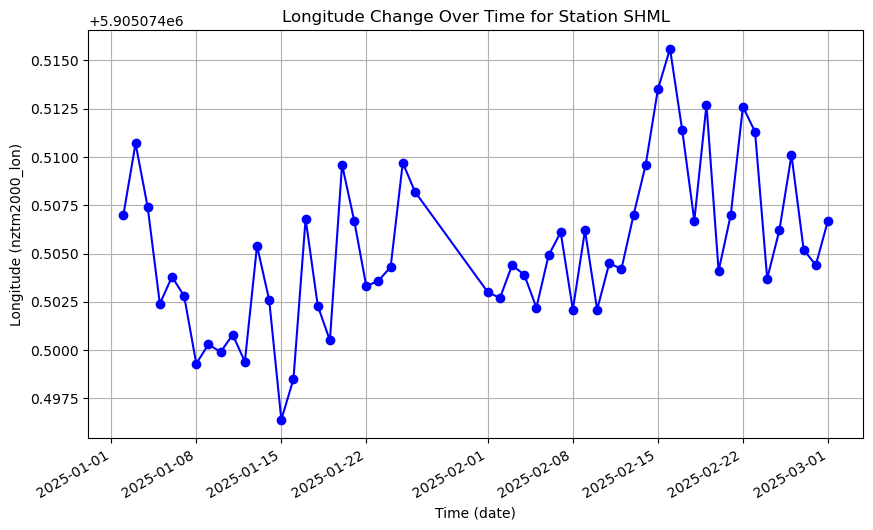

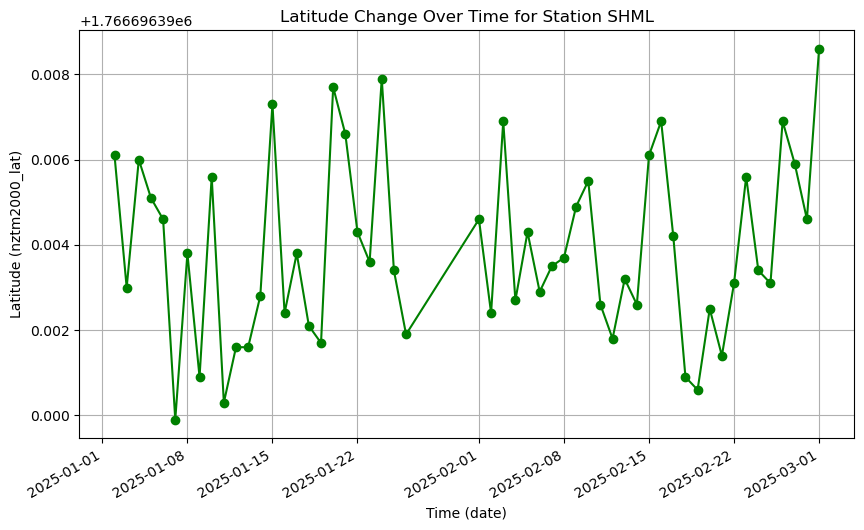

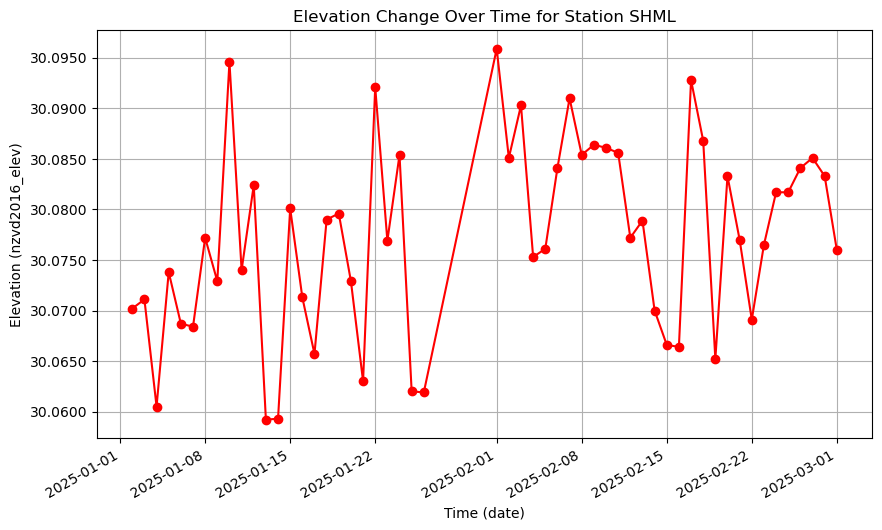

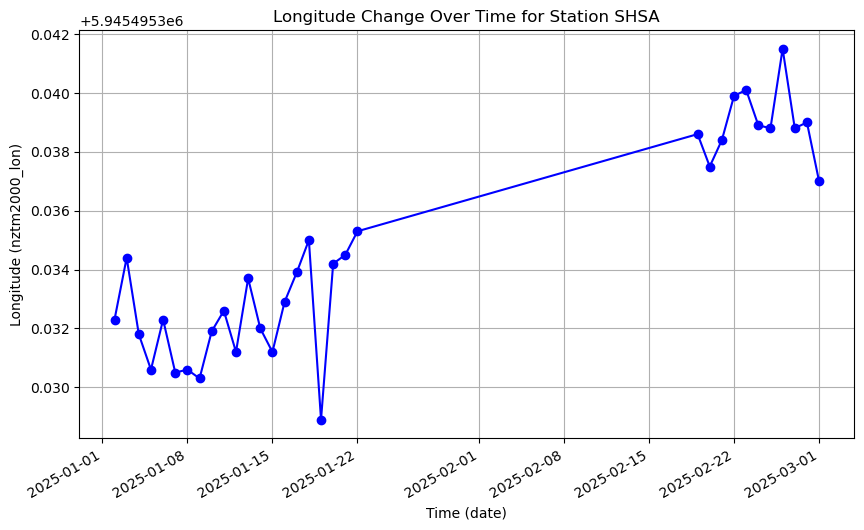

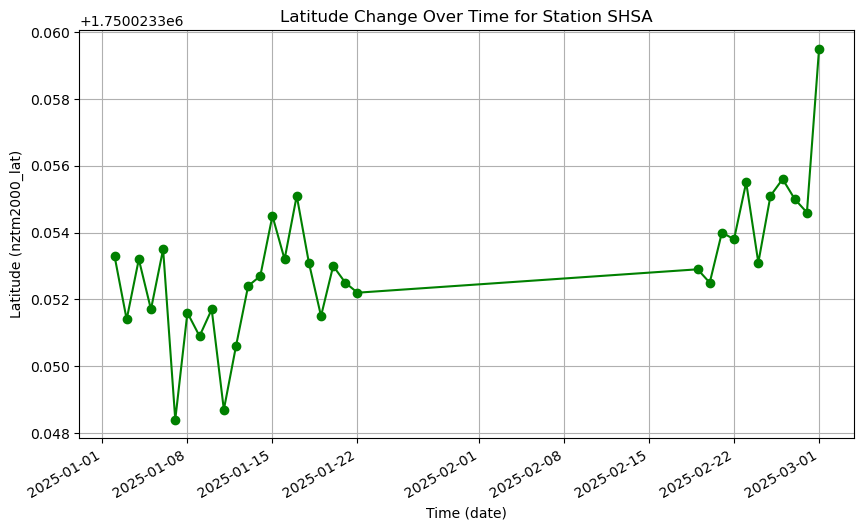

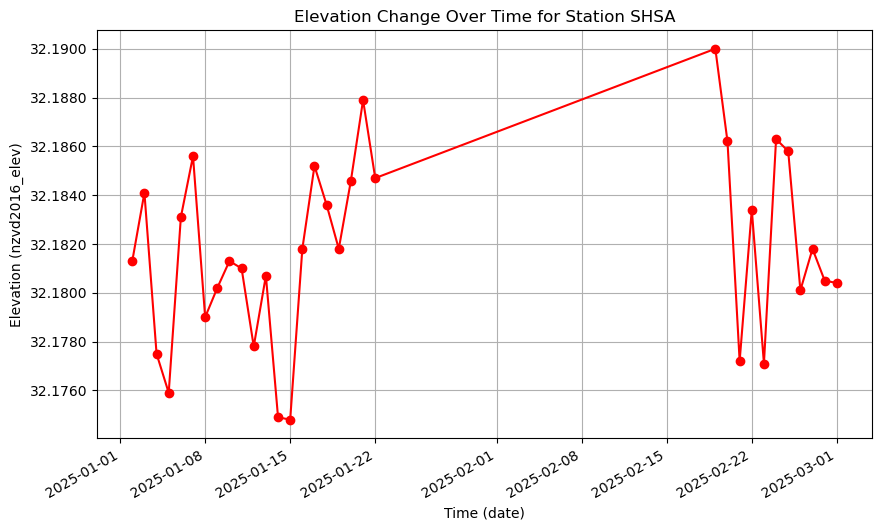

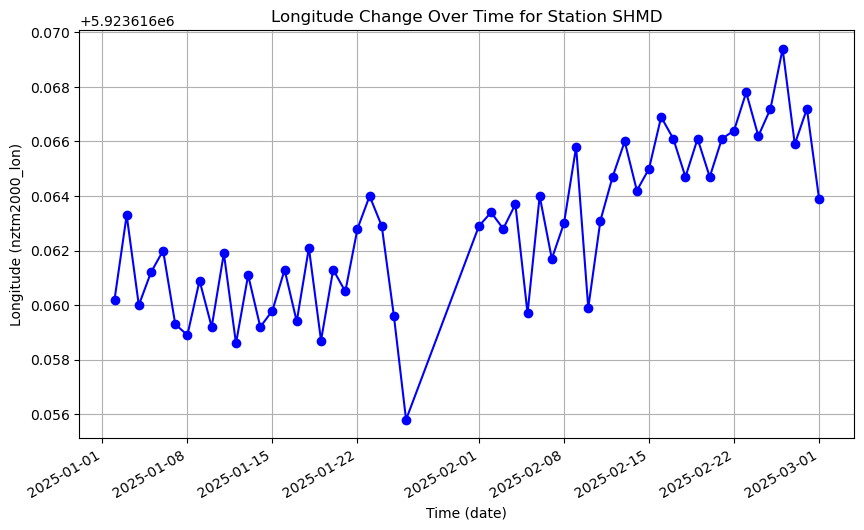

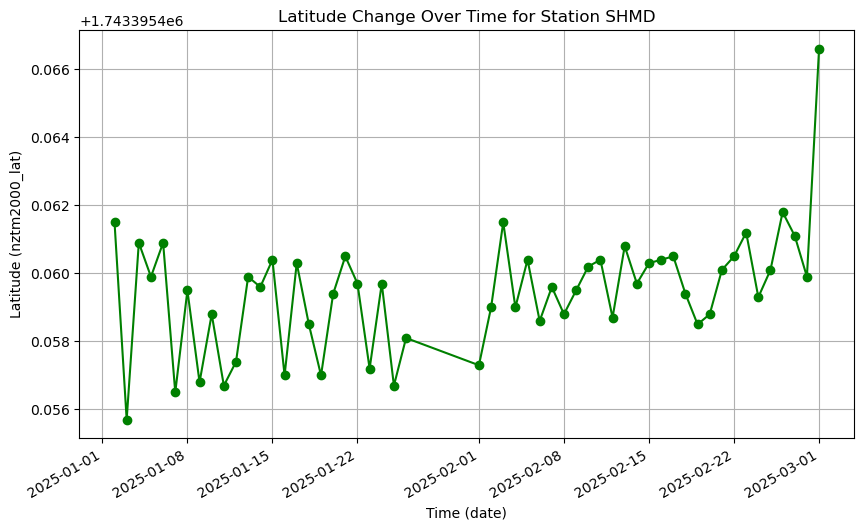

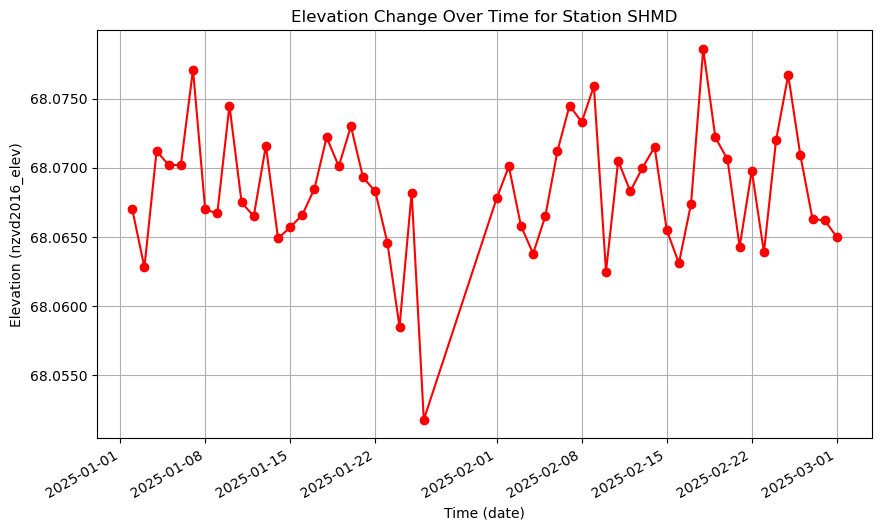

In [11]:

# Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'])

# Get unique stations
stations = df['station'].unique()

# Iterate over each station and create individual plots
for station in stations:
    station_data = df[df['station'] == station]
    
    # Plot longitude change over time
    plt.figure(figsize=(10, 6))
    plt.plot(station_data['date'], station_data['nztm2000_lon'], marker='o', linestyle='-', color='b')
    plt.title(f'Longitude Change Over Time for Station {station}')
    plt.xlabel('Time (date)')
    plt.ylabel('Longitude (nztm2000_lon)')
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.show()
    
    # Plot latitude change over time
    plt.figure(figsize=(10, 6))
    plt.plot(station_data['date'], station_data['nztm2000_lat'], marker='o', linestyle='-', color='g')
    plt.title(f'Latitude Change Over Time for Station {station}')
    plt.xlabel('Time (date)')
    plt.ylabel('Latitude (nztm2000_lat)')
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.show()
    
    # Plot elevation change over time
    plt.figure(figsize=(10, 6))
    plt.plot(station_data['date'], station_data['nzvd2016_elev'], marker='o', linestyle='-', color='r')
    plt.title(f'Elevation Change Over Time for Station {station}')
    plt.xlabel('Time (date)')
    plt.ylabel('Elevation (nzvd2016_elev)')
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.4f}'))
    plt.gcf().autofmt_xdate()
    plt.show()
